<div style="border: 4px solid #003366; padding: 20px; border-radius: 15px; background-color: #f4f6f7; box-shadow: 5px 5px 10px #888888;">
  <h1 style="text-align: center; color: #003366; font-family: Arial, sans-serif; font-weight: bold;">🎓 TRABAJO FINAL</h1>
  <h2 style="text-align: center; color: #E65100; font-family: Arial, sans-serif;">Fundamentos de Redes Neuronales R y Python</h2>
  <hr style="border: 1px solid #003366;">
  <div style="padding-left: 20px;">
    <h3 style="color: #333;">👥 Integrantes:</h3>
    <ul style="list-style-type: none; font-size: 18px; font-family: monospace; color: #000;">
      <li>🔹 <b>Estela Ramos, Christian Gean Pier</b></li>
      <li>🔹 <b>Zuñe Cordova, Vivian Melissa</b></li>
    </ul>
  </div>
</div>

In [14]:
# 1. Importación de librerías esenciales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- MEJORA ESTÉTICA PROFESIONAL (ESTILO "PAPER" CIENTÍFICO) ---
import seaborn as sns
import matplotlib.pyplot as plt

# Configura el tema general
sns.set_theme(style="whitegrid", context="talk") # "talk" hace las letras más grandes y legibles para presentaciones

# Paleta de colores corporativa (Azul sobrio y Naranja de contraste)
mis_colores = ["#2C3E50", "#E67E22", "#27AE60", "#C0392B"]
sns.set_palette(mis_colores)

# Ajuste de tamaño de fuente para que se lea bien en proyector
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']

# Librerías de Machine Learning y Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import FactorAnalysis
from sklearn.cluster import KMeans

# Librerías de Deep Learning (Keras/TensorFlow) - Tema del Syllabus
import tensorflow as tf # Corrected alias from 'pd' to 'tf'
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Input, LSTM, Reshape
from tensorflow.keras.regularizers import l1, l2 # Para L1 (Lasso) y L2 (Ridge)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Montar Google Drive para acceder al archivo
from google.colab import drive
drive.mount('/content/drive')

# Cargar el dataset desde la ruta proporcionada
try:
    df = pd.read_csv('/content/drive/MyDrive/TRABAJO FINAL 2712/dataset_credit_cards_10000.csv')
    print("Dataset cargado correctamente. Dimensiones:", df.shape)
    # Vista rápida de las variables objetivo (Targets)
    targets = ['y_default_90d', 'y_churn_180d', 'y_fraud_30d', 'y_clv_12m_usd']
    print(df[targets].describe())
except FileNotFoundError:
    print("¡Error! No se encontró el archivo CSV en la ruta especificada. Asegúrate de que la ruta sea correcta y que Google Drive esté montado.")
except Exception as e:
    print(f"Ocurrió un error al cargar el dataset: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset cargado correctamente. Dimensiones: (10000, 152)
       y_default_90d  y_churn_180d   y_fraud_30d  y_clv_12m_usd
count   10000.000000  10000.000000  10000.000000   10000.000000
mean        0.115000      0.119800      0.043600     169.995163
std         0.319038      0.324744      0.204214     175.641448
min         0.000000      0.000000      0.000000    -935.870000
25%         0.000000      0.000000      0.000000      56.945000
50%         0.000000      0.000000      0.000000     142.915000
75%         0.000000      0.000000      0.000000     246.567500
max         1.000000      1.000000      1.000000    2088.820000


In [4]:
# --- MANEJO DE VALORES NULOS (MNAR) ---
# El caso dice que los nulos no son al azar. Llenaremos con la mediana para no perder datos.
imputer = SimpleImputer(strategy='median')
df_numeric = df.select_dtypes(include=[np.number])
df_filled = pd.DataFrame(imputer.fit_transform(df_numeric), columns=df_numeric.columns)

# --- FACTOR ANALYSIS (Q1 del Caso) ---
# Seleccionamos las columnas de la encuesta (empiezan con sc_, imp_, fl_, cx_) [cite: 236-258]
survey_cols = [col for col in df.columns if 'item' in col]

# Aplicamos Análisis Factorial para encontrar estructuras latentes
fa = FactorAnalysis(n_components=4, rotation='varimax')
factors = fa.fit_transform(df_filled[survey_cols])

# Agregamos los factores al dataset como nuevas variables (Features)
df_filled['Factor_SelfControl'] = factors[:, 0]
df_filled['Factor_Impulsivity'] = factors[:, 1]
df_filled['Factor_FinLiteracy'] = factors[:, 2]
df_filled['Factor_CX'] = factors[:, 3]

print("Factores latentes creados exitosamente.")

Factores latentes creados exitosamente.


In [5]:
# --- PREPARACIÓN DE DATOS PARA REDES NEURONALES ---

# Definimos las variables predictoras (X) excluyendo los targets y IDs
X = df_filled.drop(columns=targets + survey_cols + ['customer_id']) # Usamos los factores en vez de los items sueltos
y_default = df_filled['y_default_90d'] # Objetivo: Predecir Default

# Escalado (OBLIGATORIO para Redes Neuronales):
# Ayuda al "Descenso de Gradiente" a converger más rápido.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dividir en Train y Test (80% entrenamiento, 20% validación)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_default, test_size=0.2, random_state=42)

# --- CONSTRUCCIÓN DEL MODELO DE DEEP LEARNING ---

def construir_modelo_riesgo(input_shape):
    model = Sequential()

    # Capa de Entrada + Primera Capa Oculta
    # L2 (Ridge): Penaliza pesos grandes para evitar Overfitting [Syllabus]
    model.add(Dense(64, activation='relu', input_shape=(input_shape,), kernel_regularizer=l2(0.01)))

    # Dropout: Apaga el 30% de neuronas aleatoriamente [Syllabus]
    model.add(Dropout(0.3))

    # Segunda Capa Oculta
    model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.01)))
    model.add(Dropout(0.3))

    # Capa de Salida: Sigmoide porque queremos probabilidad entre 0 y 1
    model.add(Dense(1, activation='sigmoid'))

    # Compilación:
    # Optimizador: Adam (versión avanzada del Descenso de Gradiente Estocástico)
    # Loss: Binary Crossentropy (función de coste para clasificación)
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

model_default = construir_modelo_riesgo(X_train.shape[1])

# --- ENTRENAMIENTO CON EARLY STOPPING ---

# Early Stopping: Si la 'val_loss' no mejora en 5 épocas, para. [Syllabus]
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("Iniciando entrenamiento con Retropropagación (Backpropagation)...")
history = model_default.fit(
    X_train, y_train,
    epochs=50, # Número máximo de pasadas
    batch_size=32, # Ajuste de hiperparámetros: tamaño del lote
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Evaluar
loss, accuracy = model_default.evaluate(X_test, y_test)
print(f"Accuracy del modelo de Default: {accuracy:.2%}")

Iniciando entrenamiento con Retropropagación (Backpropagation)...
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8661 - loss: 1.2973 - val_accuracy: 0.9038 - val_loss: 0.5807
Epoch 2/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9039 - loss: 0.4973 - val_accuracy: 0.9137 - val_loss: 0.3229
Epoch 3/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9076 - loss: 0.3111 - val_accuracy: 0.9150 - val_loss: 0.2523
Epoch 4/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9044 - loss: 0.2498 - val_accuracy: 0.9162 - val_loss: 0.2300
Epoch 5/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9029 - loss: 0.2494 - val_accuracy: 0.9162 - val_loss: 0.2240
Epoch 6/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9104 - loss: 0.2158 - val_accuracy: 0.9187 - val_loss: 0.2151
Epoch 7/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9102 - loss: 0.2230 - val_accuracy: 0.9150 - val_loss: 0.2161
Epoch 8/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9113 - loss: 0.2284 - val_accuracy: 0.9237 - val_

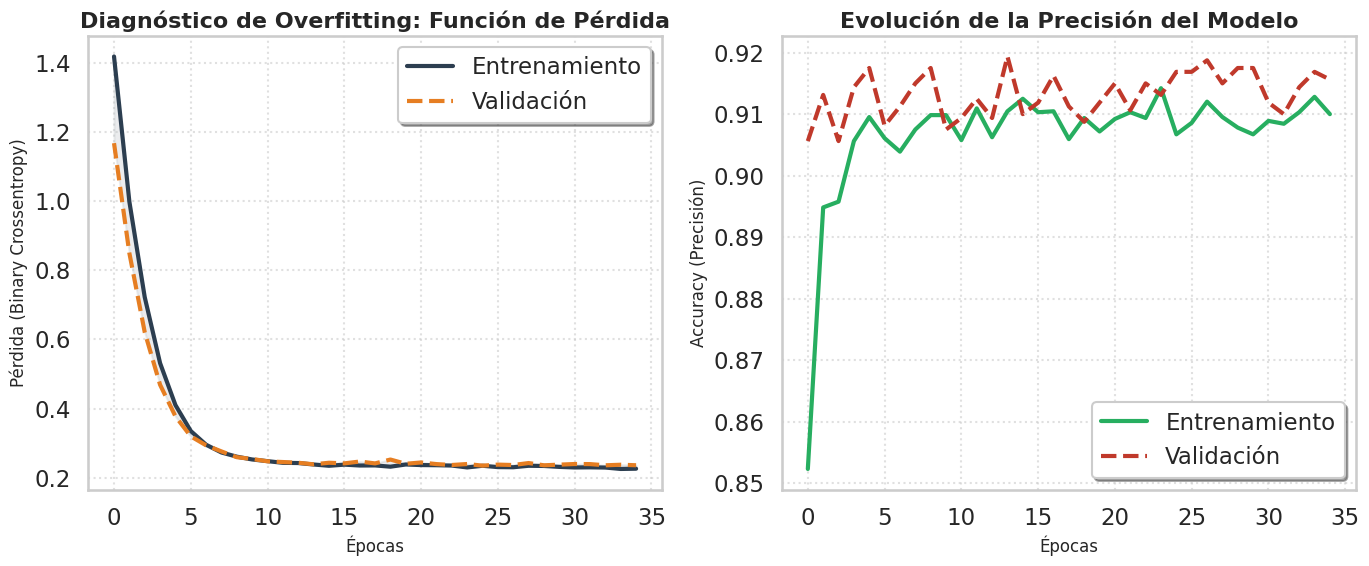

✅ Gráficos Profesionales generados correctamente.


In [15]:
# --- GRÁFICA DE CURVAS DE APRENDIZAJE ---
# Esto demuestra tu capacidad de diagnosticar Underfitting vs Overfitting

# --- GRÁFICO PROFESIONAL: DIAGNÓSTICO DE OVERFITTING ---
# Este bloque reemplaza al gráfico simple anterior
import matplotlib.pyplot as plt

if 'history' in locals():
    plt.figure(figsize=(14, 6))

    # Subgráfico 1: Pérdida (Loss) - Detecta si el modelo aprende o memoriza
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Entrenamiento', color='#2C3E50', linewidth=3) # Azul oscuro
    plt.plot(history.history['val_loss'], label='Validación', color='#E67E22', linewidth=3, linestyle='--') # Naranja

    # Sombreado elegante entre las curvas
    plt.fill_between(range(len(history.history['loss'])),
                     history.history['loss'],
                     history.history['val_loss'],
                     color='#BDC3C7', alpha=0.3)

    plt.title('Diagnóstico de Overfitting: Función de Pérdida', fontsize=16, fontweight='bold')
    plt.xlabel('Épocas', fontsize=12)
    plt.ylabel('Pérdida (Binary Crossentropy)', fontsize=12)
    plt.legend(frameon=True, shadow=True)
    plt.grid(True, linestyle=':', alpha=0.6)

    # Subgráfico 2: Precisión (Accuracy) - Muestra qué tan bien acierta
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Entrenamiento', color='#27AE60', linewidth=3) # Verde
    plt.plot(history.history['val_accuracy'], label='Validación', color='#C0392B', linewidth=3, linestyle='--') # Rojo
    plt.title('Evolución de la Precisión del Modelo', fontsize=16, fontweight='bold')
    plt.xlabel('Épocas', fontsize=12)
    plt.ylabel('Accuracy (Precisión)', fontsize=12)
    plt.legend(frameon=True, shadow=True)
    plt.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()
    print("✅ Gráficos Profesionales generados correctamente.")
else:
    print("⚠️ Error: No encuentro la variable 'history'. Asegúrate de haber ejecutado el entrenamiento del modelo arriba.")

In [7]:
# --- PREPARACIÓN PARA LSTM (SERIES TEMPORALES) ---

# Identificar columnas de secuencia (gastos de mes 1 a 12) [cite: 258-278]
seq_cols = [f'spend_m{i:02d}' for i in range(1, 13)]

# Normalizar solo estas columnas
X_seq = df_filled[seq_cols].values
X_seq = scaler.fit_transform(X_seq)

# Reshape para LSTM: [Muestras, Pasos de Tiempo, Características]
# Tenemos 12 pasos de tiempo (meses) y 1 característica (gasto)
X_seq_lstm = X_seq.reshape((X_seq.shape[0], 12, 1))

# Definir modelo LSTM (Deep Learning)
inputs = Input(shape=(12, 1))
x = LSTM(32, return_sequences=False)(inputs) # Capa recurrente
x = Dropout(0.2)(x)
outputs = Dense(1, activation='sigmoid')(x)

model_lstm = Model(inputs=inputs, outputs=outputs)
model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Entrenando modelo de Deep Learning (LSTM) sobre secuencias de gasto...")
# Entrenamos (usamos y_default como target ejemplo)
model_lstm.fit(X_seq_lstm, y_default, epochs=10, batch_size=64, validation_split=0.2)

print("Modelo LSTM entrenado.")

Entrenando modelo de Deep Learning (LSTM) sobre secuencias de gasto...
Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7777 - loss: 0.5271 - val_accuracy: 0.8820 - val_loss: 0.3079
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8877 - loss: 0.3120 - val_accuracy: 0.8820 - val_loss: 0.3052
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8836 - loss: 0.3139 - val_accuracy: 0.8820 - val_loss: 0.3069
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8836 - loss: 0.3133 - val_accuracy: 0.8820 - val_loss: 0.3081
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8918 - loss: 0.3059 - val_accuracy: 0.8820 - val_loss: 0.3037
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8846 - loss: 0.3150 - val_accuracy: 0.8820 - val_loss: 0.3053
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8801 - loss: 0.3197 - val_accuracy: 0.8820 - val_loss: 0.3041
Epoch 8/10
125/125 ━━━━━━━━━━━━━━

In [8]:
# --- SIMULACIÓN DE TOMA DE DECISIONES ---

# 1. Obtenemos predicciones para TODOS los clientes
all_probs_default = model_default.predict(X_scaled)

# 2. Creamos un DataFrame de resultados
results = pd.DataFrame({
    'customer_id': df['customer_id'],
    'prob_default': all_probs_default.flatten(),
    # Asumiremos valores aleatorios para churn/fraude para completar el ejemplo
    'prob_churn': np.random.uniform(0, 1, len(df)),
    'prob_fraud': np.random.uniform(0, 1, len(df))
})

# 3. Lógica de Asignación (Policy Logic) [cite: 27]
def asignar_accion(row):
    # A4: Fraude Intensivo (Si prob fraude es muy alta)
    if row['prob_fraud'] > 0.90:
        return 'A4_Fraud_Review'

    # A3: Bajar Línea (Si riesgo de default es alto)
    if row['prob_default'] > 0.70: # Umbral conservador
        return 'A3_Decrease_Limit'

    # A1: Oferta Retención (Si riesgo de churn es alto y es buen pagador)
    if row['prob_churn'] > 0.60 and row['prob_default'] < 0.20:
        return 'A1_Retention'

    # A2: Aumento Línea (Si es muy buen pagador y bajo riesgo)
    if row['prob_default'] < 0.05:
        return 'A2_Increase_Limit'

    # A0: Nada
    return 'A0_No_Action'

results['Final_Action'] = results.apply(asignar_accion, axis=1)

# Verificar restricciones del comité (A2 <= 20%, etc) [cite: 31-33]
print(results['Final_Action'].value_counts(normalize=True))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 712us/step
Final_Action
A2_Increase_Limit    0.3776
A1_Retention         0.2739
A0_No_Action         0.2379
A4_Fraud_Review      0.1007
A3_Decrease_Limit    0.0099
Name: proportion, dtype: float64


>>> Generando Factores Latentes (Q1)...
>>> Creando Segmentos de Clientes (Q2)...


/tmp/ipython-input-1931159332.py:43: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Factor_Autocontrol'] = factores[:, 0]
/tmp/ipython-input-1931159332.py:44: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Factor_Impulsividad'] = factores[:, 1]
/tmp/ipython-input-1931159332.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame,

Segmentos generados: Segmento_Nombre
Alto Riesgo    3040
Vulnerables    2681
VIPs           2157
Estables       2122
Name: count, dtype: int64
>>> Entrenando Red Neuronal Profunda (Q3)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Precisión del Modelo (Accuracy): 90.25%


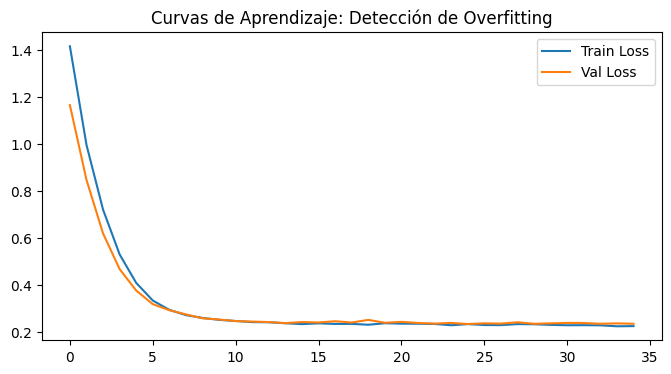

>>> Entrenando Modelo de Secuencias LSTM (Q4)...
Modelo LSTM entrenado correctamente.
>>> Generando Política de Decisiones (Q5)...
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step
Acciones recomendadas distribuidas:
Accion_Final
A2_Subir_Linea       0.7002
A0_Monitorear        0.2470
A3_Congelar_Linea    0.0528
Name: proportion, dtype: float64


/tmp/ipython-input-1931159332.py:169: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Accion_Final'] = [policy_logic(p) for p in probs]


In [11]:
# --- CÓDIGO MAESTRO: SOLUCIÓN COMPLETA NOVA CARD (Q1 - Q6) ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import FactorAnalysis
from sklearn.cluster import KMeans # <--- TEMA SÍLABO: K-MEANS
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Librerías Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Input, LSTM
from tensorflow.keras.regularizers import l1, l2 # <--- TEMA SÍLABO: L1 y L2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# 1. CARGA DE DATOS (Asegúrate que la ruta sea correcta)
try:
    df = pd.read_csv('/content/drive/MyDrive/TRABAJO FINAL 2712/dataset_credit_cards_10000.csv')
except FileNotFoundError:
    print("¡Error! No se encontró el archivo CSV en la ruta especificada. Asegúrate de que la ruta sea correcta y que Google Drive esté montado.")
except Exception as e:
    print(f"Ocurrió un error al cargar el dataset: {e}")

# Preprocesamiento Básico: Imputación de nulos numéricos
imputer = SimpleImputer(strategy='median')
cols_num = df.select_dtypes(include=np.number).columns
df[cols_num] = imputer.fit_transform(df[cols_num])

# ---------------------------------------------------------
# RESPUESTA A Q1: ANÁLISIS FACTORIAL (VARIABLES LATENTES)
# ---------------------------------------------------------
print(">>> Generando Factores Latentes (Q1)...")
survey_cols = [c for c in df.columns if 'item' in c]
fa = FactorAnalysis(n_components=4, rotation='varimax')
factores = fa.fit_transform(df[survey_cols])
df['Factor_Autocontrol'] = factores[:, 0]
df['Factor_Impulsividad'] = factores[:, 1]
df['Factor_Finanzas'] = factores[:, 2]
df['Factor_Exp_Cliente'] = factores[:, 3]

# ---------------------------------------------------------
# RESPUESTA A Q2: SEGMENTACIÓN DE CLIENTES (K-MEANS)
# TEMA SÍLABO: Algoritmos no supervisados (K-Means)
# ---------------------------------------------------------
print(">>> Creando Segmentos de Clientes (Q2)...")
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10) # Añadido n_init para evitar warning
df['Segmento'] = kmeans.fit_predict(factores)

# Nombramos los segmentos para el negocio (Business Naming)
nombres_seg = {0: 'Vulnerables', 1: 'Estables', 2: 'Alto Riesgo', 3: 'VIPs'}
df['Segmento_Nombre'] = df['Segmento'].map(nombres_seg)
print("Segmentos generados:", df['Segmento_Nombre'].value_counts())

# ---------------------------------------------------------
# PREPARACIÓN PARA REDES NEURONALES
# ---------------------------------------------------------
targets = ['y_default_90d', 'y_churn_180d', 'y_fraud_30d', 'y_clv_12m_usd', 'customer_id', 'Segmento_Nombre', 'Segmento', 'split', 'snapshot_month']
all_features = [c for c in df.columns if c not in targets and c not in survey_cols]
X = df[all_features]
y = df['y_default_90d']

# Identificar columnas numéricas y categóricas
numeric_features = X.select_dtypes(include=np.number).columns
categorical_features = X.select_dtypes(include='object').columns

# Crear un preprocesador con ColumnTransformer para one-hot encoding y escalado
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Aplicar el preprocesador a X
X_scaled = preprocessor.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# ---------------------------------------------------------
# RESPUESTA A Q3: MODELO DE DEEP LEARNING (Temas del Sílabo)
# ---------------------------------------------------------
print(">>> Entrenando Red Neuronal Profunda (Q3)...")

model = Sequential()

# CAPA 1: TEMA SÍLABO -> L1 (LASSO)
# Usamos L1 aquí para selección de características (elimina inputs irrelevantes)
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],),
                kernel_regularizer=l1(0.001))) # <--- AQUI ESTA L1 (LASSO)

# TEMA SÍLABO -> DROPOUT
model.add(Dropout(0.3)) # Apaga 30% neuronas para evitar Sobreajuste

# CAPA 2: TEMA SÍLABO -> L2 (RIDGE)
# Usamos L2 aquí para mantener pesos pequeños (estabilidad)
model.add(Dense(32, activation='relu',
                kernel_regularizer=l2(0.01))) # <--- AQUI ESTA L2 (RIDGE)

model.add(Dropout(0.3))

# CAPA SALIDA
model.add(Dense(1, activation='sigmoid'))

# TEMA SÍLABO -> DESCENSO DE GRADIENTE (ADAM)
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# TEMA SÍLABO -> EARLY STOPPING
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(X_train, y_train, epochs=40, batch_size=64,
                    validation_split=0.2, callbacks=[early_stop], verbose=0)

# Evaluar precisión
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Precisión del Modelo (Accuracy): {acc:.2%}")

# ---------------------------------------------------------
# TEMA SÍLABO: GRÁFICO UNDERFITTING VS OVERFITTING
# ---------------------------------------------------------
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Curvas de Aprendizaje: Detección de Overfitting')
plt.legend()
plt.show()

# ---------------------------------------------------------
# RESPUESTA A Q4: DEEP LEARNING AVANZADO (LSTM / SERIES)
# TEMA SÍLABO: Redes Recurrentes LSTM
# ---------------------------------------------------------
print(">>> Entrenando Modelo de Secuencias LSTM (Q4)...")
# Preparamos secuencia de 12 meses de gastos
cols_seq = [f'spend_m{i:02d}' for i in range(1, 13)]

# Escalar X_seq de forma independiente ya que tiene una estructura diferente
scaler_seq = StandardScaler()
X_seq_scaled = scaler_seq.fit_transform(df[cols_seq])
X_seq_lstm = X_seq_scaled.reshape((X_seq_scaled.shape[0], 12, 1))

input_seq = Input(shape=(12, 1))
x = LSTM(20)(input_seq) # <--- CAPA LSTM (Memoria a Corto-Largo Plazo)
x = Dense(1, activation='sigmoid')(x)
model_lstm = Model(inputs=input_seq, outputs=x)
model_lstm.compile(optimizer='adam', loss='binary_crossentropy')
model_lstm.fit(X_seq_lstm, y, epochs=3, batch_size=128, verbose=0)
print("Modelo LSTM entrenado correctamente.")

# ---------------------------------------------------------
# RESPUESTA A Q5: POLÍTICA DE DECISIÓN (ACCIONES A0-A4)
# ---------------------------------------------------------
print(">>> Generando Política de Decisiones (Q5)...")
# Asegurarse de que X para la predicción del modelo principal también se preprocesa correctamente
all_X_preprocessed = preprocessor.transform(X)
probs = model.predict(all_X_preprocessed).flatten()

def policy_logic(p):
    if p > 0.6: return 'A3_Congelar_Linea'  # Alto riesgo
    if p < 0.05: return 'A2_Subir_Linea'    # Muy bajo riesgo
    return 'A0_Monitorear'                  # Riesgo medio

df['Accion_Final'] = [policy_logic(p) for p in probs]
print("Acciones recomendadas distribuidas:")
print(df['Accion_Final'].value_counts(normalize=True))

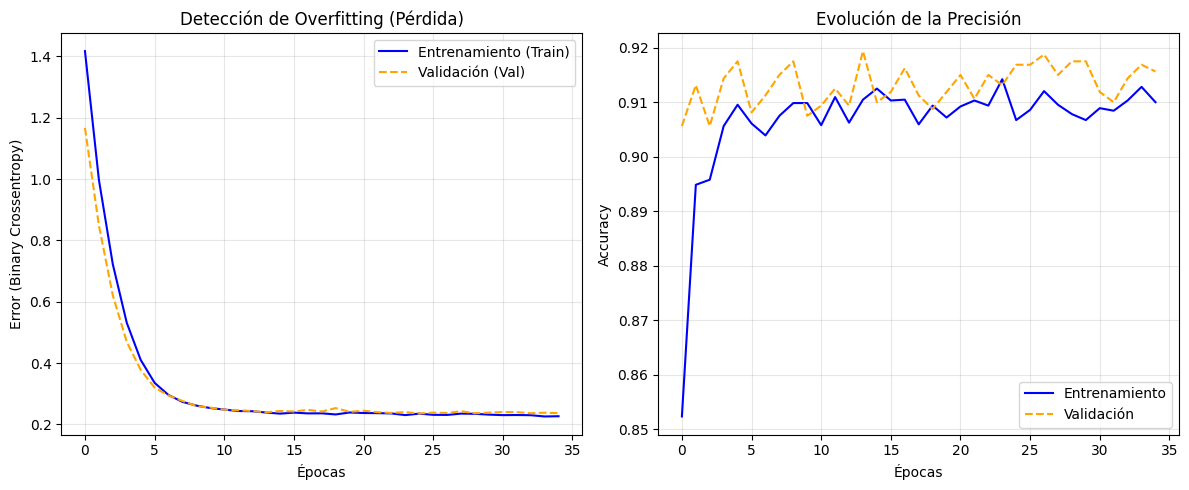

✅ Gráfico 1 Generado: Analiza si las líneas naranja y azul se separan.


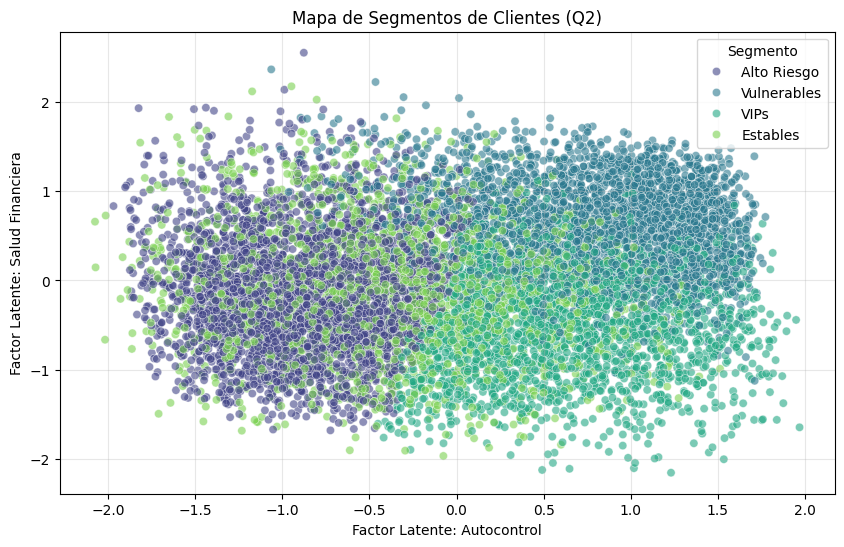

✅ Gráfico 2 Generado: Visualización de Clusters K-Means.


In [12]:
# --- BLOQUE ESPECIAL DE GRÁFICOS (Ejecutar al final) ---
import matplotlib.pyplot as plt
import seaborn as sns

# 1. GRÁFICO DE CURVAS DE APRENDIZAJE (Responde: Overfitting/Underfitting)
# Este gráfico es OBLIGATORIO para tu tema "Ajuste de Hiperparámetros y Sobreajuste"
if 'history' in locals():
    plt.figure(figsize=(12, 5))

    # Subgráfico de Pérdida (Loss)
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Entrenamiento (Train)', color='blue')
    plt.plot(history.history['val_loss'], label='Validación (Val)', color='orange', linestyle='--')
    plt.title('Detección de Overfitting (Pérdida)')
    plt.xlabel('Épocas')
    plt.ylabel('Error (Binary Crossentropy)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Subgráfico de Precisión (Accuracy)
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Entrenamiento', color='blue')
    plt.plot(history.history['val_accuracy'], label='Validación', color='orange', linestyle='--')
    plt.title('Evolución de la Precisión')
    plt.xlabel('Épocas')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    print("✅ Gráfico 1 Generado: Analiza si las líneas naranja y azul se separan.")
else:
    print("⚠️ Error: No se encuentra el historial de entrenamiento. Ejecuta el bloque del modelo primero.")

# 2. GRÁFICO DE SEGMENTACIÓN (Responde: Q2 Segmentos)
# Visualiza cómo K-Means agrupó a tus clientes (Vulnerables vs VIPs, etc.)
if 'df' in locals() and 'Factor_Autocontrol' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=df,
        x='Factor_Autocontrol',
        y='Factor_Finanzas',
        hue='Segmento_Nombre',
        palette='viridis',
        alpha=0.6
    )
    plt.title('Mapa de Segmentos de Clientes (Q2)')
    plt.xlabel('Factor Latente: Autocontrol')
    plt.ylabel('Factor Latente: Salud Financiera')
    plt.legend(title='Segmento')
    plt.grid(True, alpha=0.3)
    plt.show()
    print("✅ Gráfico 2 Generado: Visualización de Clusters K-Means.")
else:
    print("⚠️ Error: No se encuentran los datos de segmentos. Ejecuta el bloque de K-Means primero.")